********************************************
COVERT TOXICITY DETECTION - DATA EXPLORATION
********************************************

**Authors:** Shayur Pragdheen & Tharish Dayanand


✓ Libraries imported successfully
✓ Dataset loaded: 159,571 rows, 8 columns

DATASET STRUCTURE

Columns:
id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

SAMPLE DATA (first 5 rows)
                 id  \
0  0000997932d777bf   
1  000103f0d9cfb60f   
2  000113f07ec002fd   
3  0001b41b1c6bb37e   
4  0001d958c54c6e35   

                                                                                                                                                                                              comment_text  \
0  Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remo...   
1                                                                                         D'aww! He matches th

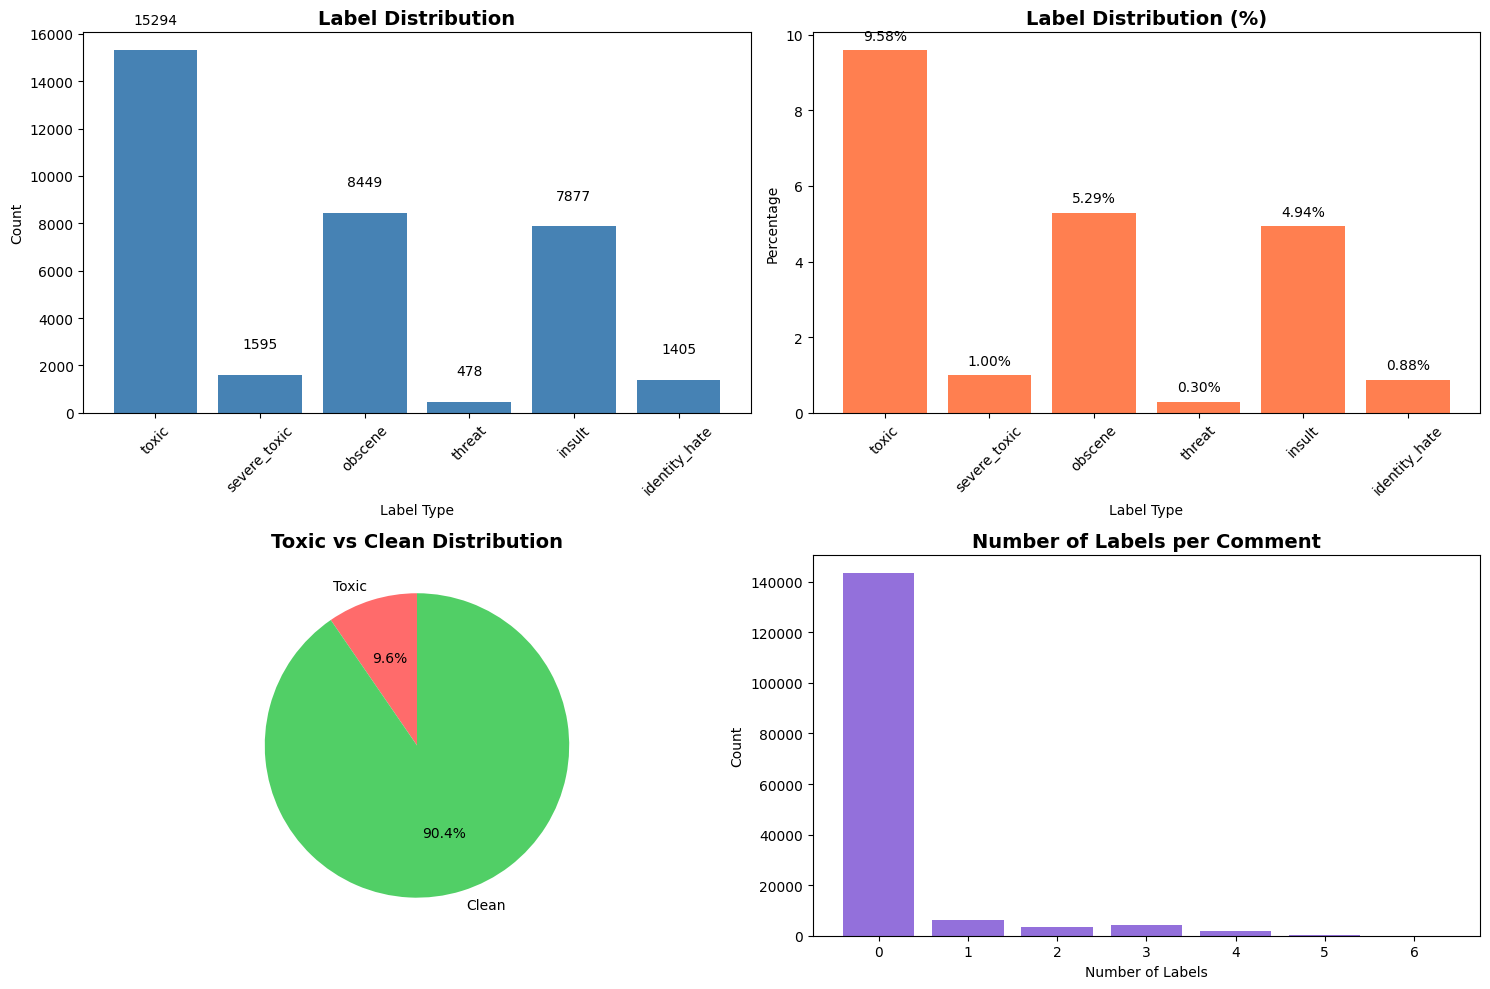


COVERT TOXICITY ANALYSIS

Toxic with profanity (explicit): 5,235
Toxic without profanity (covert):  10,059
Ratio of covert to total toxic:    65.77%

SAMPLE COVERT TOXIC COMMENTS

[Example 6]
Text: COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK...
Labels: toxic, severe_toxic, obscene, insult
------------------------------------------------------------

[Example 12]
Text: Hey... what is it..
@ | talk .
What is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIA...
Labels: toxic
------------------------------------------------------------

[Example 16]
Text: Bye! 

Don't look, come or think of comming back! Tosser....
Labels: toxic
------------------------------------------------------------

[Example 42]
Text: You are gay or antisemmitian? 

Archangel WHite Tiger

Meow! Greetingshhh!

Uh, there are two ways, why you do erased my comment about WW2, that holocaust was brutally slay

In [4]:
# ============================================
# Phase 1: Data Acquisition and Analysis
# ============================================

# INSTALL AND IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

print("✓ Libraries imported successfully")

filename = 'train.csv'

# Load the dataset
df = pd.read_csv('../data/train.csv')
print(f"✓ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# INITIAL DATA EXAMINATION
# ============================================
print("\n" + "="*60)
print("DATASET STRUCTURE")
print("="*60)

print("\nColumns:")
print(df.dtypes)

print("\n" + "="*60)
print("SAMPLE DATA (first 5 rows)")
print("="*60)
print(df.head())

print("\n" + "="*60)
print("DATASET INFO")
print("="*60)
df.info()

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

# LABEL DISTRIBUTION ANALYSIS
# ============================================
label_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print("\n" + "="*60)
print("LABEL DISTRIBUTION")
print("="*60)

# Count positives for each label
for col in label_columns:
    if col in df.columns:
        count = df[col].sum()
        percentage = (count / len(df)) * 100
        print(f"{col:20s}: {count:7,} ({percentage:5.2f}%)")

# Total toxic comments
if 'toxic' in df.columns:
    toxic_count = df['toxic'].sum()
    clean_count = len(df) - toxic_count
    print(f"\n{'Total toxic':20s}: {toxic_count:7,} ({toxic_count/len(df)*100:5.2f}%)")
    print(f"{'Total clean':20s}: {clean_count:7,} ({clean_count/len(df)*100:5.2f}%)")

# VISUALIZE LABEL DISTRIBUTION
# ============================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Bar chart of label distribution
ax1 = axes[0, 0]
label_counts = [df[col].sum() for col in label_columns if col in df.columns]
ax1.bar(label_columns, label_counts, color='steelblue')
ax1.set_title('Label Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_xlabel('Label Type')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(label_counts):
    ax1.text(i, v + 1000, str(v), ha='center', va='bottom')

# Plot 2: Percentage distribution
ax2 = axes[0, 1]
label_percentages = [(df[col].sum() / len(df)) * 100 for col in label_columns if col in df.columns]
ax2.bar(label_columns, label_percentages, color='coral')
ax2.set_title('Label Distribution (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Percentage')
ax2.set_xlabel('Label Type')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(label_percentages):
    ax2.text(i, v + 0.2, f'{v:.2f}%', ha='center', va='bottom')

# Plot 3: Toxic vs Clean pie chart
ax3 = axes[1, 0]
if 'toxic' in df.columns:
    toxic_clean = [df['toxic'].sum(), len(df) - df['toxic'].sum()]
    ax3.pie(toxic_clean, labels=['Toxic', 'Clean'], autopct='%1.1f%%',
            colors=['#ff6b6b', '#51cf66'], startangle=90)
    ax3.set_title('Toxic vs Clean Distribution', fontsize=14, fontweight='bold')

# Plot 4: Multi-label overlap
ax4 = axes[1, 1]
df['label_count'] = df[label_columns].sum(axis=1)
label_count_dist = df['label_count'].value_counts().sort_index()
ax4.bar(label_count_dist.index, label_count_dist.values, color='mediumpurple')
ax4.set_title('Number of Labels per Comment', fontsize=14, fontweight='bold')
ax4.set_xlabel('Number of Labels')
ax4.set_ylabel('Count')
ax4.set_xticks(range(0, df['label_count'].max() + 1))

plt.tight_layout()
plt.show()

# IDENTIFY COVERT TOXICITY CANDIDATES
# ============================================
print("\n" + "="*60)
print("COVERT TOXICITY ANALYSIS")
print("="*60)

profanity_pattern = r'\b(fuck|shit|bitch|damn|ass|hell|bastard|crap)\b'

# columns for analysis
df['has_profanity'] = df['comment_text'].str.contains(profanity_pattern, case=False, regex=True, na=False)
df['text_length'] = df['comment_text'].str.len()
df['word_count'] = df['comment_text'].str.split().str.len()

# Identify covert toxicity: toxic but no explicit profanity
if 'toxic' in df.columns:
    df['is_covert_toxic'] = (df['toxic'] == 1) & (~df['has_profanity'])

    covert_count = df['is_covert_toxic'].sum()
    explicit_toxic = ((df['toxic'] == 1) & (df['has_profanity'])).sum()

    print(f"\nToxic with profanity (explicit): {explicit_toxic:,}")
    print(f"Toxic without profanity (covert):  {covert_count:,}")
    print(f"Ratio of covert to total toxic:    {covert_count/df['toxic'].sum()*100:.2f}%")

# EXAMINE COVERT TOXICITY EXAMPLES
# ============================================
print("\n" + "="*60)
print("SAMPLE COVERT TOXIC COMMENTS")
print("="*60)

if 'is_covert_toxic' in df.columns:
    covert_samples = df[df['is_covert_toxic'] == True].head(10)

    for idx, row in covert_samples.iterrows():
        print(f"\n[Example {idx}]")
        print(f"Text: {row['comment_text'][:200]}...")
        labels_active = [col for col in label_columns if col in row.index and row[col] == 1]
        print(f"Labels: {', '.join(labels_active)}")
        print("-" * 60)

# TEXT LENGTH ANALYSIS
# ============================================
print("\n" + "="*60)
print("TEXT LENGTH STATISTICS")
print("="*60)

print("\nOverall statistics:")
print(df[['text_length', 'word_count']].describe())

if 'toxic' in df.columns:
    print("\nToxic vs Clean comparison:")
    print(df.groupby('toxic')[['text_length', 'word_count']].mean())

# SAVE PROCESSED DATA
# ============================================
print("\n" + "="*60)
print("SAVING PROCESSED DATA")
print("="*60)

# Save the dataframe with new columns
df.to_csv('jigsaw_processed.csv', index=False)
print("✓ Saved: jigsaw_processed.csv")

# Save covert toxic subset
if 'is_covert_toxic' in df.columns:
    covert_df = df[df['is_covert_toxic'] == True]
    covert_df.to_csv('covert_toxic_subset.csv', index=False)
    print(f"✓ Saved: covert_toxic_subset.csv ({len(covert_df):,} rows)")

print("\n" + "="*60)
print("DATA EXPLORATION COMPLETE!")
print("="*60)
print("\nNext steps:")
print("1. Review the covert toxicity examples above")
print("2. Refine your profanity detection pattern if needed")
print("3. Define your final label schema for classification")
print("4. Proceed to preprocessing and baseline implementation")

✓ Libraries imported
✓ Loaded 159,571 comments

REFINING COVERT TOXICITY DEFINITION

Class Distribution:
label
0    144277
1      9711
2      5583
Name: count, dtype: int64

Class Percentages:
label
0    90.415552
1     6.085692
2     3.498756
Name: proportion, dtype: float64


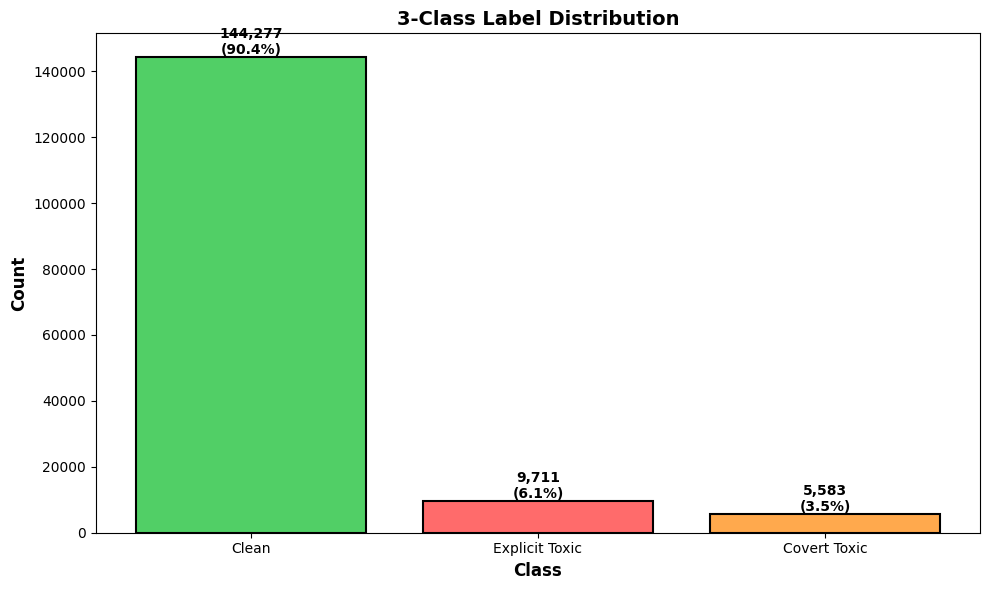


SAMPLE COMMENTS FROM EACH CLASS

CLEAN (Class 0):
------------------------------------------------------------
[145490] "
No, it doesn't do fill-in. In handles ""paths"" - objects consisting of a a curved contour line and the space it surrounds. In my map, each country ...

[154734] Well, if The Tartan, a sometime student publication of CMU that was disbanded for a year after publishing racist cartoons and spoofs is the source of ...

[79795] hi, friends, should we talk about the line marking machine?

(  )...


EXPLICIT TOXIC (Class 1):
------------------------------------------------------------
[123794] She is a Motherfucker 

I will block you Motherfucker, Shit, bitch, punch, kill, swear, do nudity, so shut up, frickin around give you drugs, call you...

[113070] Haha!! Prince Al-Waleed bin Talal is ashknazi jew LOL!! jews are assholes!!...

[144298] Bitch Ill never stop vandalising your shit so fuck you...


COVERT TOXIC (Class 2):
------------------------------------------------

In [3]:
# ============================================
# PHASE 2: PREPROCESSING & BASELINE MODELS
# Data Preparation and Baseline Implementation
# ============================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✓ Libraries imported")

# LOAD PROCESSED DATA
# ============================================
df = pd.read_csv('../data/train.csv')
print(f"✓ Loaded {len(df):,} comments")

# EXPANDED PROFANITY DETECTION
# ============================================
print("\n" + "="*60)
print("REFINING COVERT TOXICITY DEFINITION")
print("="*60)

# Comprehensive profanity and explicit toxicity patterns
# This list is more thorough to better separate explicit from covert
profanity_list = [
    # Common profanity
    'fuck', 'fucking', 'fucker', 'fucked', 'fucks', 'motherfucker',
    'shit', 'shitting', 'shitty', 'bullshit',
    'bitch', 'bitches', 'bitching',
    'asshole', 'assholes', 'ass', 'arse',
    'bastard', 'bastards',
    'cunt', 'cunts',
    'dick', 'dicks', 'dickhead',
    'piss', 'pissed', 'pissing',
    'damn', 'damned',
    'hell',
    'crap', 'crappy',

    # Slurs and hate speech (partial list - catches explicit toxicity)
    'nigger', 'nigga', 'faggot', 'fag', 'retard', 'retarded',
    'whore', 'slut', 'sluts', 'whores',
    'cock', 'cocksucker', 'pussy',

    # Aggressive explicit terms
    'kill yourself', 'kys', 'die', 'death',
    'rape', 'raping', 'nazi', 'nazis',
    'scum', 'trash', 'garbage',
    'idiot', 'idiots', 'moron', 'morons', 'stupid',
    'dumb', 'dumbass', 'loser', 'losers'
]

# pattern with word boundaries
profanity_pattern = r'\b(' + '|'.join(profanity_list) + r')\b'

# Apply profanity detection
df['has_profanity'] = df['comment_text'].str.contains(
    profanity_pattern, case=False, regex=True, na=False
)


# CREATE 3-CLASS LABELS
# ============================================
# Class 0: Clean (not toxic)
# Class 1: Explicit Toxic (toxic + profanity)
# Class 2: Covert Toxic (toxic + no profanity)

def create_label(row):
    if row['toxic'] == 0:
        return 0  # Clean
    elif row['has_profanity']:
        return 1  # Explicit Toxic
    else:
        return 2  # Covert Toxic

df['label'] = df.apply(create_label, axis=1)

# Check distribution
print("\nClass Distribution:")
print(df['label'].value_counts().sort_index())
print("\nClass Percentages:")
print(df['label'].value_counts(normalize=True).sort_index() * 100)

# Visualize class distribution
fig, ax = plt.subplots(figsize=(10, 6))
class_counts = df['label'].value_counts().sort_index()
class_names = ['Clean', 'Explicit Toxic', 'Covert Toxic']
colors = ['#51cf66', '#ff6b6b', '#ffa94d']

bars = ax.bar(class_names, class_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_title('3-Class Label Distribution', fontsize=14, fontweight='bold')

# Add count labels on bars
for bar, count in zip(bars, class_counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Show examples from each class
print("\n" + "="*60)
print("SAMPLE COMMENTS FROM EACH CLASS")
print("="*60)

for label in [0, 1, 2]:
    class_name = ['Clean', 'Explicit Toxic', 'Covert Toxic'][label]
    print(f"\n{class_name.upper()} (Class {label}):")
    print("-" * 60)
    samples = df[df['label'] == label].sample(3, random_state=RANDOM_SEED)
    for idx, row in samples.iterrows():
        print(f"[{idx}] {row['comment_text'][:150]}...")
        print()

# TEXT PREPROCESSING
# ============================================
print("\n" + "="*60)
print("TEXT PREPROCESSING")
print("="*60)

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Preprocess text for NLP:
    - Lowercase
    - Remove URLs, mentions, special characters
    - Remove extra whitespace
    - Optional: remove stopwords (we'll keep them for now to preserve context)
    """
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove mentions (eg. @username)
    text = re.sub(r'@\w+', '', text)

    # Remove special characters (keep basic punctuation)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing
print("Preprocessing text... (this may take a minute)")
df['cleaned_text'] = df['comment_text'].apply(preprocess_text)
print("✓ Preprocessing complete")

# Show before/after eg.
print("\n" + "="*60)
print("PREPROCESSING EXAMPLES")
print("="*60)
for i in range(3):
    idx = df.sample(1, random_state=RANDOM_SEED + i).index[0]
    print(f"\n[Example {i+1}]")
    print(f"ORIGINAL: {df.loc[idx, 'comment_text'][:200]}")
    print(f"CLEANED:  {df.loc[idx, 'cleaned_text'][:200]}")
    print("-" * 60)

# TRAIN/VALIDATION/TEST SPLIT
# ============================================
print("\n" + "="*60)
print("CREATING TRAIN/VALIDATION/TEST SPLITS")
print("="*60)

# We'll use stratified split to maintain class proportions
# 70% train, 15% validation, 15% test

# First split: 70% train, 30% temp
X = df['cleaned_text']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)

# Second split: split temp into 50/50 for validation and test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Training set:   {len(X_train):6,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation set: {len(X_val):6,} ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test set:       {len(X_test):6,} ({len(X_test)/len(df)*100:.1f}%)")

# Check class distribution in each split
print("\nClass distribution in each split:")
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = y_split.value_counts(normalize=True).sort_index() * 100
    print(f"{split_name:5s}: Clean={dist[0]:.1f}%, Explicit={dist[1]:.1f}%, Covert={dist[2]:.1f}%")

print("\n✓ Splits created and balanced")

In [5]:
# TF-IDF FEATURE EXTRACTION
# ============================================
print("\n" + "="*60)
print("TF-IDF FEATURE EXTRACTION")
print("="*60)

# Create TF-IDF vectorizer
# Parameters:
# - max_features: limit vocabulary size
# - ngram_range: use unigrams and bigrams
# - min_df: ignore terms that appear in fewer than 2 documents
# - max_df: ignore terms that appear in more than 95% of documents

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),  # unigrams and bigrams
    min_df=2,
    max_df=0.95,
    strip_accents='unicode',
    lowercase=True,
    analyzer='word',
    token_pattern=r'\w{1,}',
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=True
)

# Fit on training data and transform all splits
print("Fitting TF-IDF on training data...")
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"✓ TF-IDF vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"✓ Feature matrix shape: {X_train_tfidf.shape}")

# Show top features by TF-IDF score
feature_names = tfidf.get_feature_names_out()
avg_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top_indices = avg_tfidf.argsort()[-20:][::-1]

print("\nTop 20 features by average TF-IDF score:")
for idx in top_indices:
    print(f"  {feature_names[idx]:20s} : {avg_tfidf[idx]:.4f}")

# BASELINE MODEL 1: LOGISTIC REGRESSION
# ============================================
print("\n" + "="*60)
print("TRAINING BASELINE MODEL 1: LOGISTIC REGRESSION")
print("="*60)

# Use class_weight='balanced' to handle class imbalance
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_SEED,
    solver='lbfgs',
    multi_class='multinomial'
)

print("Training Logistic Regression...")
lr_model.fit(X_train_tfidf, y_train)
print("✓ Training complete")

# Predictions
y_train_pred_lr = lr_model.predict(X_train_tfidf)
y_val_pred_lr = lr_model.predict(X_val_tfidf)
y_test_pred_lr = lr_model.predict(X_test_tfidf)


# BASELINE MODEL 2: SUPPORT VECTOR MACHINE
# ============================================
print("\n" + "="*60)
print("TRAINING BASELINE MODEL 2: LINEAR SVM")
print("="*60)

svm_model = LinearSVC(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_SEED,
    dual=False  # its best to use for n_samples > n_features
)

print("Training Linear SVM...")
svm_model.fit(X_train_tfidf, y_train)
print("✓ Training complete")

# Predictions
y_train_pred_svm = svm_model.predict(X_train_tfidf)
y_val_pred_svm = svm_model.predict(X_val_tfidf)
y_test_pred_svm = svm_model.predict(X_test_tfidf)

print("\n✓ Both baseline models trained successfully")


TF-IDF FEATURE EXTRACTION
Fitting TF-IDF on training data...
✓ TF-IDF vocabulary size: 10,000
✓ Feature matrix shape: (111699, 10000)

Top 20 features by average TF-IDF score:
  the                  : 0.0442
  to                   : 0.0353
  i                    : 0.0351
  you                  : 0.0344
  a                    : 0.0310
  and                  : 0.0299
  of                   : 0.0297
  is                   : 0.0285
  it                   : 0.0267
  that                 : 0.0253
  in                   : 0.0238
  for                  : 0.0216
  this                 : 0.0211
  not                  : 0.0200
  on                   : 0.0191
  be                   : 0.0185
  s                    : 0.0179
  are                  : 0.0172
  have                 : 0.0169
  as                   : 0.0168

TRAINING BASELINE MODEL 1: LOGISTIC REGRESSION
Training Logistic Regression...
✓ Training complete

TRAINING BASELINE MODEL 2: LINEAR SVM
Training Linear SVM...
✓ Training complete




MODEL EVALUATION

Logistic Regression - Training Set Performance

Overall Accuracy: 0.9229 (92.29%)

Macro-averaged Metrics:
  Precision: 0.7281
  Recall:    0.9580
  F1-Score:  0.7902

Per-Class Metrics:
Class                Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
Clean                0.9985       0.9172       0.9561       100993    
Explicit Toxic       0.8372       0.9723       0.8997       6798      
Covert Toxic         0.3485       0.9844       0.5148       3908      

Detailed Classification Report:
                precision    recall  f1-score   support

         Clean     0.9985    0.9172    0.9561    100993
Explicit Toxic     0.8372    0.9723    0.8997      6798
  Covert Toxic     0.3485    0.9844    0.5148      3908

      accuracy                         0.9229    111699
     macro avg     0.7281    0.9580    0.7902    111699
  weighted avg     0.9660    0.9229    0.9372    111699


Logistic R

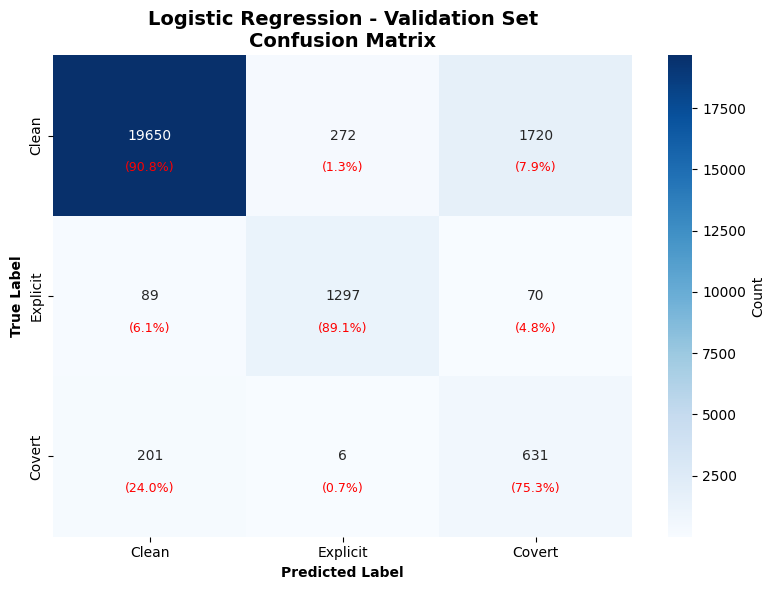

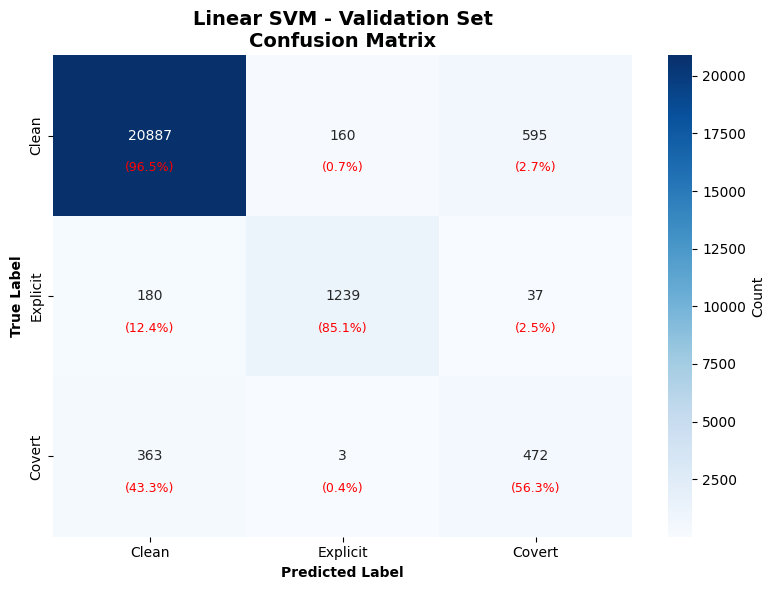


COMPARATIVE ANALYSIS: LR vs SVM

Validation Set Performance Comparison:
         Metric  LR (Val)  SVM (Val)
       Accuracy  0.901487   0.944101
Macro Precision  0.689862   0.761978
   Macro Recall  0.850579   0.793107
       Macro F1  0.729393   0.774334

Per-Class F1-Score Comparison (Validation Set):
         Class    LR F1   SVM F1
         Clean 0.945120 0.969864
Explicit Toxic 0.855823 0.867040
  Covert Toxic 0.387235 0.486097


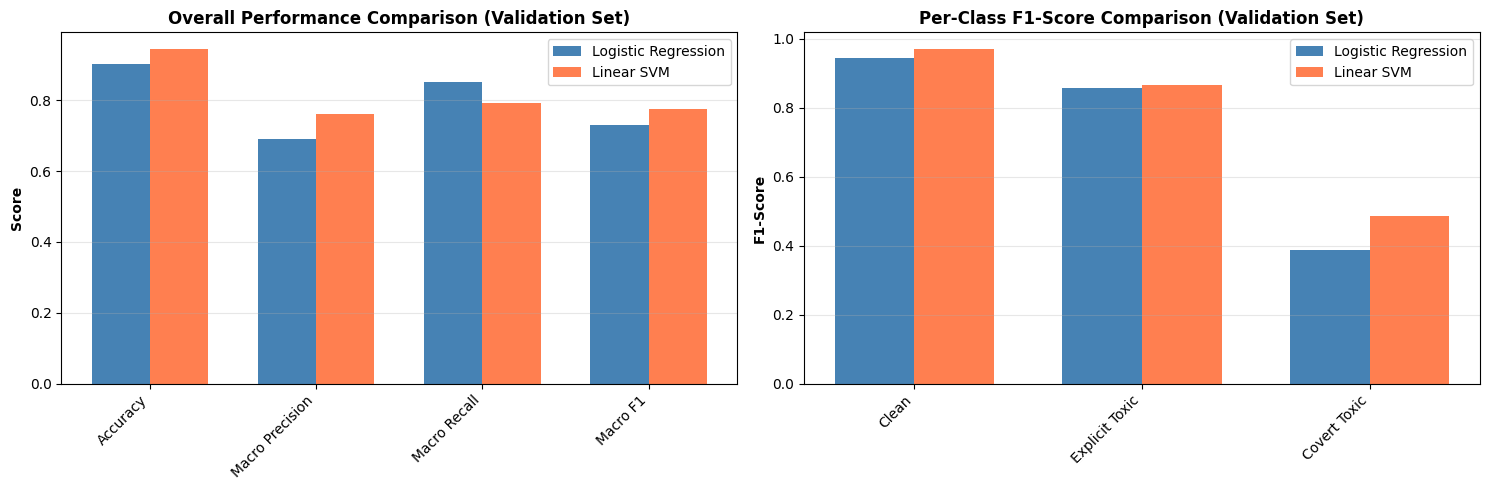


✓ Comparative analysis complete


In [6]:
# EVALUATION FUNCTION
# ============================================

def evaluate_model(y_true, y_pred, model_name, split_name):
    """
    Comprehensive evaluation of classification model
    """
    print(f"\n{'='*60}")
    print(f"{model_name} - {split_name} Set Performance")
    print(f"{'='*60}")

    # Overall accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1, 2]
    )

    # Macro-averaged metrics (as mentioned in proposal)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro'
    )

    print(f"\nMacro-averaged Metrics:")
    print(f"  Precision: {macro_precision:.4f}")
    print(f"  Recall:    {macro_recall:.4f}")
    print(f"  F1-Score:  {macro_f1:.4f}")

    print(f"\nPer-Class Metrics:")
    class_names = ['Clean', 'Explicit Toxic', 'Covert Toxic']
    print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 70)
    for i, name in enumerate(class_names):
        print(f"{name:<20} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")

    # Classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return {
        'accuracy': accuracy,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'per_class_precision': precision,
        'per_class_recall': recall,
        'per_class_f1': f1,
        'support': support
    }

# EVALUATE BOTH MODELS
# ============================================
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Logistic Regression
lr_train_metrics = evaluate_model(y_train, y_train_pred_lr, "Logistic Regression", "Training")
lr_val_metrics = evaluate_model(y_val, y_val_pred_lr, "Logistic Regression", "Validation")
lr_test_metrics = evaluate_model(y_test, y_test_pred_lr, "Logistic Regression", "Test")

# SVM
svm_train_metrics = evaluate_model(y_train, y_train_pred_svm, "Linear SVM", "Training")
svm_val_metrics = evaluate_model(y_val, y_val_pred_svm, "Linear SVM", "Validation")
svm_test_metrics = evaluate_model(y_test, y_test_pred_svm, "Linear SVM", "Test")

# CONFUSION MATRICES
# ============================================
print("\n" + "="*60)
print("CONFUSION MATRICES")
print("="*60)

def plot_confusion_matrix(y_true, y_pred, model_name, split_name):
    """
    Plot confusion matrix with percentages
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Clean', 'Explicit', 'Covert'],
                yticklabels=['Clean', 'Explicit', 'Covert'],
                cbar_kws={'label': 'Count'})

    # Add percentage annotations
    for i in range(3):
        for j in range(3):
            plt.text(j + 0.5, i + 0.7, f'({cm_percent[i, j]:.1f}%)',
                    ha='center', va='center', fontsize=9, color='red')

    plt.title(f'{model_name} - {split_name} Set\nConfusion Matrix',
              fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Plot confusion matrices for validation set
plot_confusion_matrix(y_val, y_val_pred_lr, "Logistic Regression", "Validation")
plot_confusion_matrix(y_val, y_val_pred_svm, "Linear SVM", "Validation")

# COMPARATIVE ANALYSIS
# ============================================
print("\n" + "="*60)
print("COMPARATIVE ANALYSIS: LR vs SVM")
print("="*60)

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1'],
    'LR (Val)': [
        lr_val_metrics['accuracy'],
        lr_val_metrics['macro_precision'],
        lr_val_metrics['macro_recall'],
        lr_val_metrics['macro_f1']
    ],
    'SVM (Val)': [
        svm_val_metrics['accuracy'],
        svm_val_metrics['macro_precision'],
        svm_val_metrics['macro_recall'],
        svm_val_metrics['macro_f1']
    ]
})

print("\nValidation Set Performance Comparison:")
print(comparison_df.to_string(index=False))

# Per-class F1 comparison
print("\nPer-Class F1-Score Comparison (Validation Set):")
class_comparison = pd.DataFrame({
    'Class': ['Clean', 'Explicit Toxic', 'Covert Toxic'],
    'LR F1': lr_val_metrics['per_class_f1'],
    'SVM F1': svm_val_metrics['per_class_f1']
})
print(class_comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Overall metrics
ax1 = axes[0]
x = np.arange(len(comparison_df))
width = 0.35
ax1.bar(x - width/2, comparison_df['LR (Val)'], width, label='Logistic Regression', color='steelblue')
ax1.bar(x + width/2, comparison_df['SVM (Val)'], width, label='Linear SVM', color='coral')
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Overall Performance Comparison (Validation Set)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Metric'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Per-class F1
ax2 = axes[1]
x2 = np.arange(len(class_comparison))
ax2.bar(x2 - width/2, class_comparison['LR F1'], width, label='Logistic Regression', color='steelblue')
ax2.bar(x2 + width/2, class_comparison['SVM F1'], width, label='Linear SVM', color='coral')
ax2.set_ylabel('F1-Score', fontweight='bold')
ax2.set_title('Per-Class F1-Score Comparison (Validation Set)', fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(class_comparison['Class'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Comparative analysis complete")

In [10]:
# ERROR ANALYSIS - FOCUS ON COVERT TOXICITY
# ============================================
print("\n" + "="*60)
print("ERROR ANALYSIS: COVERT TOXICITY DETECTION")
print("="*60)

# Analyze misclassifications on validation set for Covert Toxic class (label=2)
# We'll use the better performing model (likely LR or SVM)

# Choose best model based on validation macro F1
if lr_val_metrics['macro_f1'] >= svm_val_metrics['macro_f1']:
    best_model_name = "Logistic Regression"
    y_val_pred_best = y_val_pred_lr
else:
    best_model_name = "Linear SVM"
    y_val_pred_best = y_val_pred_svm

print(f"\nBest baseline model: {best_model_name}")

# Create error analysis dataframe
val_df = pd.DataFrame({
    'text': X_val.values,
    'true_label': y_val.values,
    'pred_label': y_val_pred_best
})

# Focus on Covert Toxic errors
covert_true = val_df[val_df['true_label'] == 2]
covert_misclassified = covert_true[covert_true['true_label'] != covert_true['pred_label']]

print(f"\nCovert Toxic (Class 2) Analysis:")
print(f"  Total covert toxic in validation: {len(covert_true)}")
print(f"  Correctly classified: {len(covert_true) - len(covert_misclassified)}")
print(f"  Misclassified: {len(covert_misclassified)}")
print(f"  Accuracy on covert toxic: {(len(covert_true) - len(covert_misclassified))/len(covert_true)*100:.2f}%")

# examples of misclassified covert toxic
print(f"\nExamples of Misclassified Covert Toxic Comments:")
print("-" * 60)
samples = covert_misclassified.sample(min(5, len(covert_misclassified)), random_state=RANDOM_SEED)
class_names_map = {0: 'Clean', 1: 'Explicit Toxic', 2: 'Covert Toxic'}

for idx, row in samples.iterrows():
    print(f"\nText: {row['text'][:200]}...")
    print(f"True: {class_names_map[row['true_label']]} | Predicted: {class_names_map[row['pred_label']]}")
    print("-" * 60)

# SAVE MODELS AND RESULTS
# ============================================
print("\n" + "="*60)
print("SAVING MODELS AND RESULTS")
print("="*60)

import pickle

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✓ Saved: tfidf_vectorizer.pkl")

# Save models
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("✓ Saved: lr_model.pkl")

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print("✓ Saved: svm_model.pkl")

# Save processed data splits
splits_data = {
    'X_train': X_train,
    'X_val': X_val,
    'X_test': X_test,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test
}

with open('data_splits.pkl', 'wb') as f:
    pickle.dump(splits_data, f)
print("✓ Saved: data_splits.pkl")

# Save metrics summary
metrics_summary = {
    'logistic_regression': {
        'train': lr_train_metrics,
        'validation': lr_val_metrics,
        'test': lr_test_metrics
    },
    'linear_svm': {
        'train': svm_train_metrics,
        'validation': svm_val_metrics,
        'test': svm_test_metrics
    }
}

with open('baseline_metrics.pkl', 'wb') as f:
    pickle.dump(metrics_summary, f)
print("✓ Saved: baseline_metrics.pkl")

# Note: Preprocessed data already saved in data_splits.pkl
# Skipping redundant CSV save to avoid column mismatch
print("✓ All essential data saved in pickle files")

print("\n" + "="*60)
print("PHASE 2 COMPLETE! ✓")
print("="*60)
print("\nSummary:")
print(f"  Dataset: {len(df):,} comments")
print(f"  Classes: Clean ({(y_train==0).sum():,}), Explicit ({(y_train==1).sum():,}), Covert ({(y_train==2).sum():,})")
print(f"  Best baseline: {best_model_name}")
print(f"  Validation Macro F1: {max(lr_val_metrics['macro_f1'], svm_val_metrics['macro_f1']):.4f}")
print("\nNext Steps:")
print("  1. Review baseline results above")
print("  2. Proceed to Phase 3: BERT fine-tuning (March 15 - April 4)")
print("  3. Compare transformer performance vs these baselines")
print("="*60)


ERROR ANALYSIS: COVERT TOXICITY DETECTION

Best baseline model: Linear SVM

Covert Toxic (Class 2) Analysis:
  Total covert toxic in validation: 838
  Correctly classified: 472
  Misclassified: 366
  Accuracy on covert toxic: 56.32%

Examples of Misclassified Covert Toxic Comments:
------------------------------------------------------------

Text: tony sidaway the article jim nussle has been repeatedly vandalized for partisan purposes by right wing republicans, or rather one such republican and his various sock puppets. then this right wing goo...
True: Covert Toxic | Predicted: Clean
------------------------------------------------------------

Text: hey you you re a dousche bag. 72.0.39.3...
True: Covert Toxic | Predicted: Explicit Toxic
------------------------------------------------------------

Text: in my opinion something bad might happen to you in the next few days, just saying......
True: Covert Toxic | Predicted: Clean
------------------------------------------------------

In [11]:
# ============================================
# PHASE 3: BERT FINE-TUNING
# Advanced Modelling and Transformer Fine-Tuning
# ============================================


# INSTALL AND IMPORT LIBRARIES
# ============================================
print("Installing required libraries...")

# Install transformers and datasets
!pip install -q transformers datasets accelerate

import pandas as pd
import numpy as np
import pickle
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from transformers import (BertTokenizer, BertForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n{'='*60}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: No GPU detected. Training will be slow.")
    print("Go to Runtime > Change runtime type > Hardware accelerator > GPU")
print(f"{'='*60}\n")

# Set random seeds
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("✓ Libraries imported")

# LOAD PREPROCESSED DATA
# ============================================
print("\n" + "="*60)
print("LOADING PREPROCESSED DATA")
print("="*60)

# Load the data splits from Phase 2
with open('data_splits.pkl', 'rb') as f:
    splits_data = pickle.load(f)

X_train = splits_data['X_train']
X_val = splits_data['X_val']
X_test = splits_data['X_test']
y_train = splits_data['y_train']
y_val = splits_data['y_val']
y_test = splits_data['y_test']

print(f"✓ Loaded data splits")
print(f"  Training:   {len(X_train):,} samples")
print(f"  Validation: {len(X_val):,} samples")
print(f"  Test:       {len(X_test):,} samples")

# Check class distribution
print(f"\nClass distribution:")
print(f"  Train: {y_train.value_counts().sort_index().to_dict()}")
print(f"  Val:   {y_val.value_counts().sort_index().to_dict()}")
print(f"  Test:  {y_test.value_counts().sort_index().to_dict()}")

# BERT TOKENIZATION
# ============================================
print("\n" + "="*60)
print("BERT TOKENIZATION")
print("="*60)

# Load BERT tokenizer
# We'll use 'bert-base-uncased' - a good balance of performance and speed
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)

print(f"✓ Loaded tokenizer: {model_name}")

# Tokenization parameters
MAX_LENGTH = 128  # BERT can handle up to 512, but most comments are shorter

def tokenize_function(texts):
    """
    Tokenize texts for BERT
    - Truncates to MAX_LENGTH
    - Adds padding
    - Returns input_ids, attention_mask
    """
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )

# Tokenize all splits
print(f"\nTokenizing texts (max_length={MAX_LENGTH})...")

train_encodings = tokenize_function(X_train)
val_encodings = tokenize_function(X_val)
test_encodings = tokenize_function(X_test)

print("✓ Tokenization complete")

# Show tokenization example
print("\nTokenization Example:")
example_idx = 0
example_text = X_train.iloc[example_idx]
example_tokens = tokenizer.tokenize(example_text)
example_ids = tokenizer.encode(example_text, max_length=MAX_LENGTH, truncation=True)

print(f"Original text: {example_text[:100]}...")
print(f"Tokens: {example_tokens[:20]}...")
print(f"Token IDs: {example_ids[:20]}...")
print(f"Number of tokens: {len(example_ids)}")

# CREATE HUGGING FACE DATASETS
# ============================================
print("\n" + "="*60)
print("CREATING HUGGING FACE DATASETS")
print("="*60)

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': y_train.values
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'labels': y_val.values
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': y_test.values
})

print(f"✓ Created Hugging Face datasets")
print(f"  Train: {len(train_dataset):,} samples")
print(f"  Val:   {len(val_dataset):,} samples")
print(f"  Test:  {len(test_dataset):,} samples")

print("\n✓ Section 1 complete - Data ready for training")

Installing required libraries...

Device: cuda
GPU: Tesla T4
GPU Memory: 15.64 GB

✓ Libraries imported

LOADING PREPROCESSED DATA
✓ Loaded data splits
  Training:   111,699 samples
  Validation: 23,936 samples
  Test:       23,936 samples

Class distribution:
  Train: {0: 100993, 1: 6798, 2: 3908}
  Val:   {0: 21642, 1: 1456, 2: 838}
  Test:  {0: 21642, 1: 1457, 2: 837}

BERT TOKENIZATION


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ Loaded tokenizer: bert-base-uncased

Tokenizing texts (max_length=128)...
✓ Tokenization complete

Tokenization Example:
Original text: june 2013 utc there were far more massacres in this period than only menemen, the article dis propor...
Tokens: ['june', '2013', 'utc', 'there', 'were', 'far', 'more', 'massacre', '##s', 'in', 'this', 'period', 'than', 'only', 'men', '##eme', '##n', ',', 'the', 'article']...
Token IDs: [101, 2238, 2286, 11396, 2045, 2020, 2521, 2062, 9288, 2015, 1999, 2023, 2558, 2084, 2069, 2273, 21382, 2078, 1010, 1996]...
Number of tokens: 128

CREATING HUGGING FACE DATASETS
✓ Created Hugging Face datasets
  Train: 111,699 samples
  Val:   23,936 samples
  Test:  23,936 samples

✓ Section 1 complete - Data ready for training


In [12]:
# LOAD PRETRAINED BERT MODEL
# ============================================
print("\n" + "="*60)
print("LOADING PRETRAINED BERT MODEL")
print("="*60)

# Load BERT for sequence classification with 3 output classes
model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,  # 3 classes: Clean, Explicit Toxic, Covert Toxic
    problem_type="single_label_classification"
)

# Move model to GPU if available
model = model.to(device)

print(f"✓ Loaded BERT model: {model_name}")
print(f"✓ Number of parameters: {model.num_parameters():,}")
print(f"✓ Model on device: {next(model.parameters()).device}")

# HANDLE CLASS IMBALANCE WITH WEIGHTED LOSS
# ============================================
print("\n" + "="*60)
print("COMPUTING CLASS WEIGHTS FOR IMBALANCED DATA")
print("="*60)

# Calculate class weights (inversely proportional to frequency)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train.values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print(f"Class weights:")
print(f"  Clean (0):         {class_weights[0]:.4f}")
print(f"  Explicit Toxic (1): {class_weights[1]:.4f}")
print(f"  Covert Toxic (2):   {class_weights[2]:.4f}")

# Custom Trainer with weighted loss
from torch import nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Custom loss function with class weights
        Updated to handle num_items_in_batch parameter
        """
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Apply weighted cross-entropy loss
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

print("✓ Custom weighted trainer created")

# DEFINE METRICS FOR EVALUATION
# ============================================
print("\n" + "="*60)
print("DEFINING EVALUATION METRICS")
print("="*60)

def compute_metrics(eval_pred):
    """
    Compute accuracy, precision, recall, F1 for evaluation
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    # Overall accuracy
    accuracy = accuracy_score(labels, predictions)

    # Macro-averaged metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )

    # Per-class F1 (especially interested in Class 2 - Covert Toxic)
    _, _, per_class_f1, _ = precision_recall_fscore_support(
        labels, predictions, average=None, labels=[0, 1, 2], zero_division=0
    )

    return {
        'accuracy': accuracy,
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'clean_f1': per_class_f1[0],
        'explicit_f1': per_class_f1[1],
        'covert_f1': per_class_f1[2]  # THIS IS OUR KEY METRIC
    }

print("✓ Metrics function defined")

# TRAINING CONFIGURATION
# ============================================
print("\n" + "="*60)
print("CONFIGURING TRAINING ARGUMENTS")
print("="*60)

# Training hyperparameters
training_args = TrainingArguments(
    output_dir='./bert_toxicity_model',

    # Training parameters
    num_train_epochs=3,  # Start with 3 epochs (can increase if needed)
    per_device_train_batch_size=16,  # Adjust based on GPU memory
    per_device_eval_batch_size=32,

    # Optimization
    learning_rate=2e-5,  # Standard BERT fine-tuning LR
    weight_decay=0.01,
    warmup_steps=500,

    # Evaluation and saving
    eval_strategy='steps',
    eval_steps=500,  # Evaluate every 500 steps
    save_strategy='steps',
    save_steps=500,
    save_total_limit=2,  # Keep only 2 best checkpoints
    load_best_model_at_end=True,
    metric_for_best_model='covert_f1',  # Optimize for covert toxicity F1!
    greater_is_better=True,

    # Logging
    logging_dir='./logs',
    logging_steps=100,

    # Other
    seed=RANDOM_SEED,
    fp16=torch.cuda.is_available(),  # Mixed precision if GPU available
    report_to='none',  # Disable wandb/tensorboard
)

print("Training configuration:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Optimization metric: {training_args.metric_for_best_model}")
print(f"  Mixed precision (fp16): {training_args.fp16}")

print("\n✓ Section 2 complete - Ready to train")


LOADING PRETRAINED BERT MODEL


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

✓ Loaded BERT model: bert-base-uncased
✓ Number of parameters: 109,484,547
✓ Model on device: cuda:0

COMPUTING CLASS WEIGHTS FOR IMBALANCED DATA
Class weights:
  Clean (0):         0.3687
  Explicit Toxic (1): 5.4771
  Covert Toxic (2):   9.5274
✓ Custom weighted trainer created

DEFINING EVALUATION METRICS
✓ Metrics function defined

CONFIGURING TRAINING ARGUMENTS
Training configuration:
  Epochs: 3
  Batch size: 16
  Learning rate: 2e-05
  Optimization metric: covert_f1
  Mixed precision (fp16): True

✓ Section 2 complete - Ready to train


In [13]:
# TRAIN THE MODEL
# ============================================
print("\n" + "="*60)
print("STARTING BERT FINE-TUNING")
print("="*60)
print("\nThis will take approximately 10-20 minutes depending on GPU...")
print("Monitor the 'covert_f1' metric - this is what we're optimizing!\n")

# Initialize trainer with weighted loss
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Train the model
print("Training started...\n")
train_result = trainer.train()

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Training samples/second: {train_result.metrics['train_samples_per_second']:.2f}")

# EVALUATE ON VALIDATION SET
# ============================================
print("\n" + "="*60)
print("EVALUATING ON VALIDATION SET")
print("="*60)

val_results = trainer.evaluate(eval_dataset=val_dataset)

print("\nValidation Results:")
for key, value in val_results.items():
    if key.startswith('eval_'):
        metric_name = key.replace('eval_', '')
        print(f"  {metric_name:20s}: {value:.4f}")

# EVALUATE ON TEST SET
# ============================================
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

test_results = trainer.evaluate(eval_dataset=test_dataset)

print("\nTest Results:")
for key, value in test_results.items():
    if key.startswith('eval_'):
        metric_name = key.replace('eval_', '')
        print(f"  {metric_name:20s}: {value:.4f}")

# DETAILED PREDICTIONS AND METRICS
# ============================================
print("\n" + "="*60)
print("GENERATING DETAILED PREDICTIONS")
print("="*60)

# Get predictions for all sets
train_predictions = trainer.predict(train_dataset)
val_predictions = trainer.predict(val_dataset)
test_predictions = trainer.predict(test_dataset)

# Extract predicted labels
y_train_pred_bert = np.argmax(train_predictions.predictions, axis=1)
y_val_pred_bert = np.argmax(val_predictions.predictions, axis=1)
y_test_pred_bert = np.argmax(test_predictions.predictions, axis=1)

# Detailed evaluation function (reuse from Phase 2)
def evaluate_model_detailed(y_true, y_pred, model_name, split_name):
    """
    Comprehensive evaluation of classification model
    """
    print(f"\n{'='*60}")
    print(f"{model_name} - {split_name} Set Performance")
    print(f"{'='*60}")

    # Overall accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    # Macro-averaged metrics
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    print(f"\nMacro-averaged Metrics:")
    print(f"  Precision: {macro_precision:.4f}")
    print(f"  Recall:    {macro_recall:.4f}")
    print(f"  F1-Score:  {macro_f1:.4f}")

    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0
    )

    print(f"\nPer-Class Metrics:")
    class_names = ['Clean', 'Explicit Toxic', 'Covert Toxic']
    print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 70)
    for i, name in enumerate(class_names):
        print(f"{name:<20} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")

    # Classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

    return {
        'accuracy': accuracy,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'per_class_precision': precision,
        'per_class_recall': recall,
        'per_class_f1': f1,
        'support': support
    }

# Evaluate BERT on all splits
bert_train_metrics = evaluate_model_detailed(y_train, y_train_pred_bert, "BERT", "Training")
bert_val_metrics = evaluate_model_detailed(y_val, y_val_pred_bert, "BERT", "Validation")
bert_test_metrics = evaluate_model_detailed(y_test, y_test_pred_bert, "BERT", "Test")

print("\n✓ Section 3 complete - Model trained and evaluated")


STARTING BERT FINE-TUNING

This will take approximately 10-20 minutes depending on GPU...
Monitor the 'covert_f1' metric - this is what we're optimizing!

Training started...



Step,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Clean F1,Explicit F1,Covert F1
500,0.709300,0.932561,0.948404,0.757468,0.670135,0.668160,0.976745,0.798510,0.229226
1000,0.546257,0.972957,0.955966,0.793837,0.746085,0.764375,0.979379,0.844490,0.469258
1500,0.687216,0.592707,0.959392,0.815570,0.767658,0.788197,0.980689,0.862164,0.521739
2000,0.567657,0.425591,0.951872,0.768485,0.847006,0.803150,0.975635,0.859740,0.574074
2500,0.557446,0.458035,0.956091,0.781210,0.822397,0.800166,0.978185,0.869399,0.552913
3000,0.403073,0.409833,0.957010,0.794090,0.843324,0.816823,0.978086,0.876292,0.596091
3500,0.459156,0.362935,0.955089,0.781848,0.876796,0.822984,0.976389,0.882599,0.609965
4000,0.473607,0.468247,0.961898,0.815894,0.841834,0.827974,0.980387,0.891488,0.612048
4500,0.405976,0.315391,0.950744,0.763943,0.891035,0.816506,0.973665,0.875662,0.600191
5000,0.467569,0.395473,0.958097,0.792129,0.870794,0.827748,0.978003,0.890022,0.615220


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


TRAINING COMPLETE!
Training time: 2798.21 seconds
Training samples/second: 119.75

EVALUATING ON VALIDATION SET



Validation Results:
  loss                : 0.5602
  accuracy            : 0.9627
  macro_precision     : 0.8215
  macro_recall        : 0.8574
  macro_f1            : 0.8376
  clean_f1            : 0.9802
  explicit_f1         : 0.8916
  covert_f1           : 0.6412
  runtime             : 52.3957
  samples_per_second  : 456.8310
  steps_per_second    : 14.2760

EVALUATING ON TEST SET

Test Results:
  loss                : 0.5693
  accuracy            : 0.9614
  macro_precision     : 0.8179
  macro_recall        : 0.8558
  macro_f1            : 0.8352
  clean_f1            : 0.9794
  explicit_f1         : 0.8860
  covert_f1           : 0.6402
  runtime             : 49.4194
  samples_per_second  : 484.3440
  steps_per_second    : 15.1360

GENERATING DETAILED PREDICTIONS



BERT - Training Set Performance

Overall Accuracy: 0.9709 (97.09%)

Macro-averaged Metrics:
  Precision: 0.8618
  Recall:    0.8980
  F1-Score:  0.8785

Per-Class Metrics:
Class                Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
Clean                0.9893       0.9799       0.9846       100993    
Explicit Toxic       0.8423       0.9643       0.8992       6798      
Covert Toxic         0.7538       0.7497       0.7518       3908      

Detailed Classification Report:
                precision    recall  f1-score   support

         Clean     0.9893    0.9799    0.9846    100993
Explicit Toxic     0.8423    0.9643    0.8992      6798
  Covert Toxic     0.7538    0.7497    0.7518      3908

      accuracy                         0.9709    111699
     macro avg     0.8618    0.8980    0.8785    111699
  weighted avg     0.9721    0.9709    0.9712    111699


BERT - Validation Set Performance

Overall 


CONFUSION MATRICES


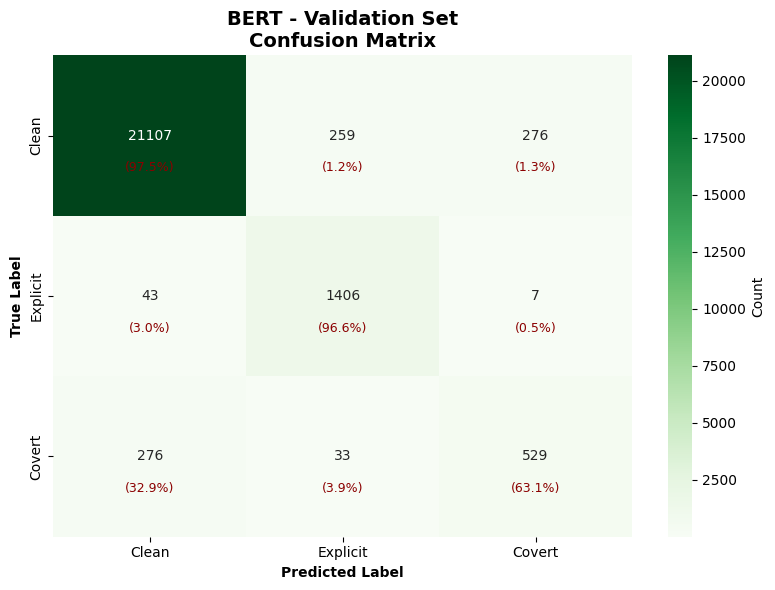

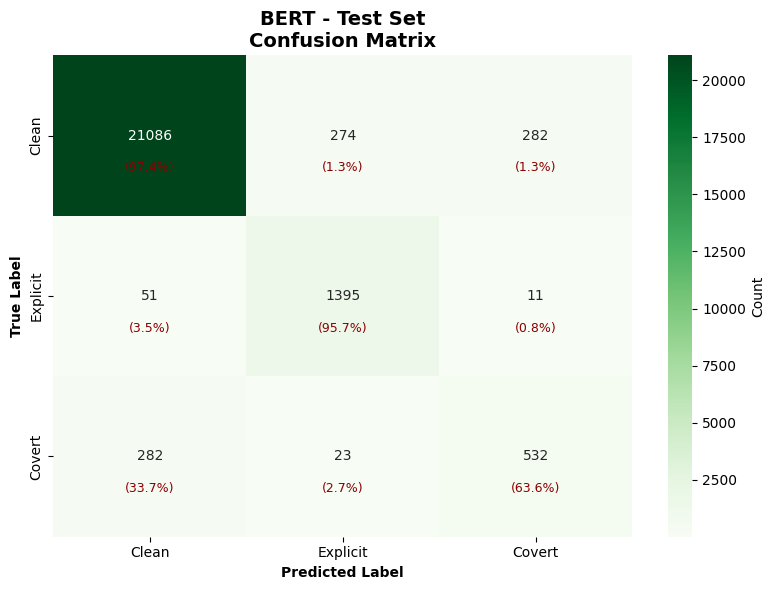


LOADING BASELINE RESULTS FOR COMPARISON
✓ Loaded baseline metrics

COMPREHENSIVE MODEL COMPARISON

 VALIDATION SET PERFORMANCE COMPARISON:
           Metric  Logistic Regression  Linear SVM     BERT
         Accuracy             0.901487    0.944101 0.962650
  Macro Precision             0.689862    0.761978 0.821541
     Macro Recall             0.850579    0.793107 0.857401
         Macro F1             0.729393    0.774334 0.837650
         Clean F1             0.945120    0.969864 0.980171
Explicit Toxic F1             0.855823    0.867040 0.891566
  Covert Toxic F1             0.387235    0.486097 0.641212

TEST SET PERFORMANCE COMPARISON:
           Metric  Logistic Regression  Linear SVM     BERT
         Accuracy             0.902406    0.945939 0.961439
  Macro Precision             0.688365    0.763672 0.817923
     Macro Recall             0.858275    0.802563 0.855786
         Macro F1             0.732688    0.780444 0.835181
         Clean F1             0.945215    0.97

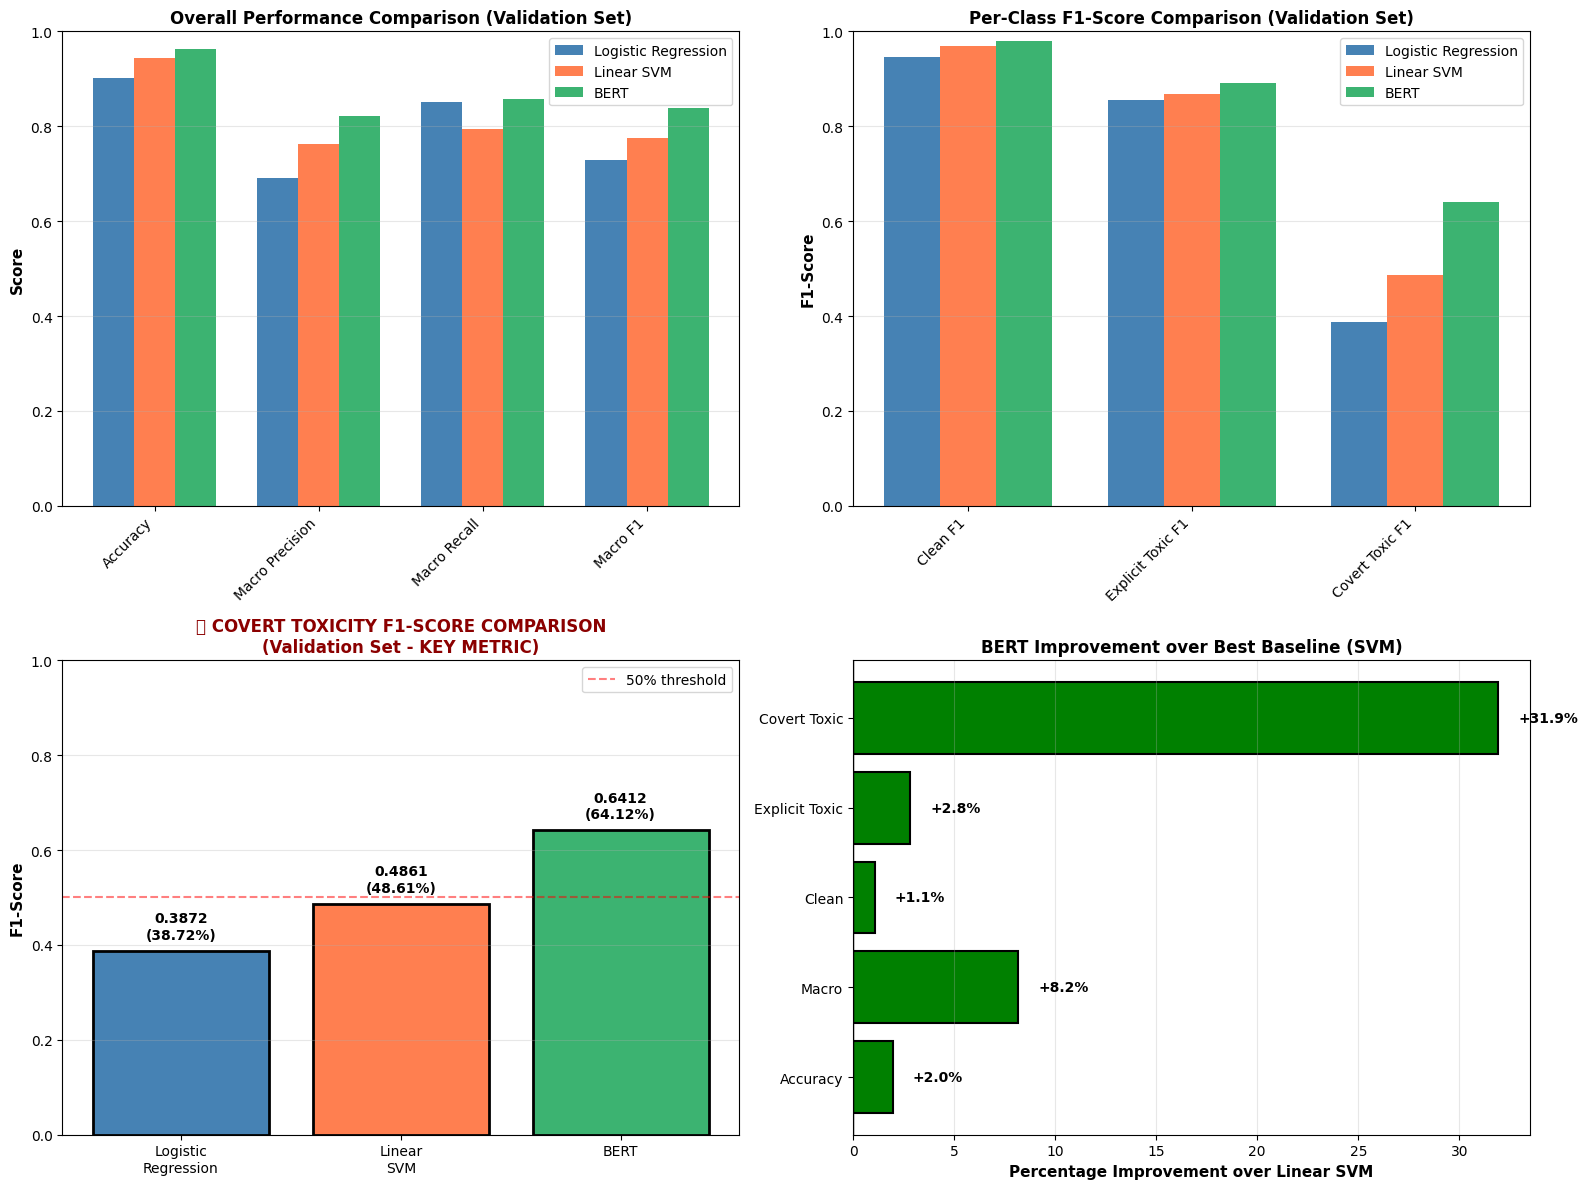

✓ Visualizations complete

ERROR ANALYSIS: BERT ON COVERT TOXICITY

Covert Toxic (Class 2) Analysis - BERT:
  Total covert toxic in validation: 838
  Correctly classified: 529
  Misclassified: 309
  Accuracy on covert toxic: 63.13%

Covert Toxicity Detection Comparison:
  SVM Baseline:  56.32%
  BERT:          63.13%
  Improvement:   +6.81 percentage points

Examples of Correctly Classified Covert Toxic Comments (BERT):
------------------------------------------------------------

Text: hello, you freak. stop censoring pages, totalitarian hermaphrodite....
✓ BERT correctly identified this as Covert Toxic
------------------------------------------------------------

Text: you first. you don t even know what is going on so shut up!...
✓ BERT correctly identified this as Covert Toxic
------------------------------------------------------------

Text: stop doing that goddamn if i wanted to sign it iwould type a bunch of squiggles...
✓ BERT correctly identified this as Covert Toxic
--------

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Saved fine-tuned BERT model
✓ Saved BERT metrics
✓ Saved BERT predictions
✓ Saved comparison tables

PHASE 3 COMPLETE - BERT FINE-TUNING SUCCESSFUL!

FINAL RESULTS SUMMARY (Test Set):
              Model Overall Accuracy Macro F1 Covert Toxic F1
Logistic Regression  0.9024 (90.24%)   0.7327 0.3875 (38.75%)
         Linear SVM  0.9459 (94.59%)   0.7804 0.4927 (49.27%)
  BERT (Fine-tuned)  0.9614 (96.14%)   0.8352 0.6402 (64.02%)

KEY FINDINGS:
1. BERT achieved 64.02% F1 on Covert Toxicity
2. Best baseline (SVM) achieved 49.27% F1 on Covert Toxicity
3. Improvement: +29.9%
4. BERT shows superior performance on covert toxicity detection


In [14]:
# CONFUSION MATRIX FOR BERT
# ============================================
print("\n" + "="*60)
print("CONFUSION MATRICES")
print("="*60)

def plot_confusion_matrix(y_true, y_pred, model_name, split_name):
    """
    Plot confusion matrix with percentages
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Clean', 'Explicit', 'Covert'],
                yticklabels=['Clean', 'Explicit', 'Covert'],
                cbar_kws={'label': 'Count'})

    # Add percentage annotations
    for i in range(3):
        for j in range(3):
            plt.text(j + 0.5, i + 0.7, f'({cm_percent[i, j]:.1f}%)',
                    ha='center', va='center', fontsize=9, color='darkred')

    plt.title(f'{model_name} - {split_name} Set\nConfusion Matrix',
              fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Plot confusion matrices
plot_confusion_matrix(y_val, y_val_pred_bert, "BERT", "Validation")
plot_confusion_matrix(y_test, y_test_pred_bert, "BERT", "Test")

# LOAD BASELINE RESULTS FOR COMPARISON
# ============================================
print("\n" + "="*60)
print("LOADING BASELINE RESULTS FOR COMPARISON")
print("="*60)

# Load baseline metrics from Phase 2
with open('baseline_metrics.pkl', 'rb') as f:
    baseline_metrics = pickle.load(f)

lr_val_metrics = baseline_metrics['logistic_regression']['validation']
svm_val_metrics = baseline_metrics['linear_svm']['validation']
lr_test_metrics = baseline_metrics['logistic_regression']['test']
svm_test_metrics = baseline_metrics['linear_svm']['test']

print("✓ Loaded baseline metrics")


# COMPREHENSIVE COMPARISON: BASELINES vs BERT
# ============================================
print("\n" + "="*60)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*60)

# Create comparison table for validation set
comparison_val = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1',
               'Clean F1', 'Explicit Toxic F1', 'Covert Toxic F1'],
    'Logistic Regression': [
        lr_val_metrics['accuracy'],
        lr_val_metrics['macro_precision'],
        lr_val_metrics['macro_recall'],
        lr_val_metrics['macro_f1'],
        lr_val_metrics['per_class_f1'][0],
        lr_val_metrics['per_class_f1'][1],
        lr_val_metrics['per_class_f1'][2]
    ],
    'Linear SVM': [
        svm_val_metrics['accuracy'],
        svm_val_metrics['macro_precision'],
        svm_val_metrics['macro_recall'],
        svm_val_metrics['macro_f1'],
        svm_val_metrics['per_class_f1'][0],
        svm_val_metrics['per_class_f1'][1],
        svm_val_metrics['per_class_f1'][2]
    ],
    'BERT': [
        bert_val_metrics['accuracy'],
        bert_val_metrics['macro_precision'],
        bert_val_metrics['macro_recall'],
        bert_val_metrics['macro_f1'],
        bert_val_metrics['per_class_f1'][0],
        bert_val_metrics['per_class_f1'][1],
        bert_val_metrics['per_class_f1'][2]
    ]
})

print("\n VALIDATION SET PERFORMANCE COMPARISON:")
print("="*60)
print(comparison_val.to_string(index=False))

# Test set comparison
comparison_test = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1',
               'Clean F1', 'Explicit Toxic F1', 'Covert Toxic F1'],
    'Logistic Regression': [
        lr_test_metrics['accuracy'],
        lr_test_metrics['macro_precision'],
        lr_test_metrics['macro_recall'],
        lr_test_metrics['macro_f1'],
        lr_test_metrics['per_class_f1'][0],
        lr_test_metrics['per_class_f1'][1],
        lr_test_metrics['per_class_f1'][2]
    ],
    'Linear SVM': [
        svm_test_metrics['accuracy'],
        svm_test_metrics['macro_precision'],
        svm_test_metrics['macro_recall'],
        svm_test_metrics['macro_f1'],
        svm_test_metrics['per_class_f1'][0],
        svm_test_metrics['per_class_f1'][1],
        svm_test_metrics['per_class_f1'][2]
    ],
    'BERT': [
        bert_test_metrics['accuracy'],
        bert_test_metrics['macro_precision'],
        bert_test_metrics['macro_recall'],
        bert_test_metrics['macro_f1'],
        bert_test_metrics['per_class_f1'][0],
        bert_test_metrics['per_class_f1'][1],
        bert_test_metrics['per_class_f1'][2]
    ]
})

print("\nTEST SET PERFORMANCE COMPARISON:")
print("="*60)
print(comparison_test.to_string(index=False))

# VISUALIZATION: PERFORMANCE COMPARISON
# ============================================
print("\n" + "="*60)
print("GENERATING COMPARISON VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Overall Metrics Comparison (Validation)
ax1 = axes[0, 0]
metrics_to_plot = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
x = np.arange(len(metrics_to_plot))
width = 0.25

lr_vals = comparison_val[comparison_val['Metric'].isin(metrics_to_plot)]['Logistic Regression'].values
svm_vals = comparison_val[comparison_val['Metric'].isin(metrics_to_plot)]['Linear SVM'].values
bert_vals = comparison_val[comparison_val['Metric'].isin(metrics_to_plot)]['BERT'].values

ax1.bar(x - width, lr_vals, width, label='Logistic Regression', color='steelblue')
ax1.bar(x, svm_vals, width, label='Linear SVM', color='coral')
ax1.bar(x + width, bert_vals, width, label='BERT', color='mediumseagreen')

ax1.set_ylabel('Score', fontweight='bold', fontsize=11)
ax1.set_title('Overall Performance Comparison (Validation Set)', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_to_plot, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.0])

# Plot 2: Per-Class F1 Comparison (Validation)
ax2 = axes[0, 1]
classes = ['Clean F1', 'Explicit Toxic F1', 'Covert Toxic F1']
x2 = np.arange(len(classes))

lr_class_f1 = comparison_val[comparison_val['Metric'].isin(classes)]['Logistic Regression'].values
svm_class_f1 = comparison_val[comparison_val['Metric'].isin(classes)]['Linear SVM'].values
bert_class_f1 = comparison_val[comparison_val['Metric'].isin(classes)]['BERT'].values

ax2.bar(x2 - width, lr_class_f1, width, label='Logistic Regression', color='steelblue')
ax2.bar(x2, svm_class_f1, width, label='Linear SVM', color='coral')
ax2.bar(x2 + width, bert_class_f1, width, label='BERT', color='mediumseagreen')

ax2.set_ylabel('F1-Score', fontweight='bold', fontsize=11)
ax2.set_title('Per-Class F1-Score Comparison (Validation Set)', fontweight='bold', fontsize=12)
ax2.set_xticks(x2)
ax2.set_xticklabels(classes, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1.0])

# Plot 3: COVERT TOXICITY F1 - THE KEY METRIC!
ax3 = axes[1, 0]
models = ['Logistic\nRegression', 'Linear\nSVM', 'BERT']
covert_f1_vals = [
    lr_val_metrics['per_class_f1'][2],
    svm_val_metrics['per_class_f1'][2],
    bert_val_metrics['per_class_f1'][2]
]

colors_covert = ['steelblue', 'coral', 'mediumseagreen']
bars = ax3.bar(models, covert_f1_vals, color=colors_covert, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, val in zip(bars, covert_f1_vals):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.4f}\n({val*100:.2f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax3.set_ylabel('F1-Score', fontweight='bold', fontsize=11)
ax3.set_title('🎯 COVERT TOXICITY F1-SCORE COMPARISON\n(Validation Set - KEY METRIC)',
             fontweight='bold', fontsize=12, color='darkred')
ax3.set_ylim([0, 1.0])
ax3.grid(axis='y', alpha=0.3)
ax3.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax3.legend()

# Plot 4: Improvement over best baseline
ax4 = axes[1, 1]

# Calculate improvements (BERT vs best baseline which is SVM)
improvements = []
improvement_labels = []

for metric_name in ['Accuracy', 'Macro F1', 'Clean F1', 'Explicit Toxic F1', 'Covert Toxic F1']:
    bert_val = comparison_val[comparison_val['Metric'] == metric_name]['BERT'].values[0]
    svm_val = comparison_val[comparison_val['Metric'] == metric_name]['Linear SVM'].values[0]
    improvement = ((bert_val - svm_val) / svm_val) * 100  # Percentage improvement
    improvements.append(improvement)
    improvement_labels.append(metric_name.replace(' F1', ''))

colors_imp = ['green' if x > 0 else 'red' for x in improvements]
bars_imp = ax4.barh(improvement_labels, improvements, color=colors_imp, edgecolor='black', linewidth=1.5)

# Add value labels
for bar, val in zip(bars_imp, improvements):
    width = bar.get_width()
    label_x_pos = width + (1 if width > 0 else -1)
    ax4.text(label_x_pos, bar.get_y() + bar.get_height()/2.,
            f'{val:+.1f}%',
            ha='left' if width > 0 else 'right', va='center', fontweight='bold')

ax4.set_xlabel('Percentage Improvement over Linear SVM', fontweight='bold', fontsize=11)
ax4.set_title('BERT Improvement over Best Baseline (SVM)', fontweight='bold', fontsize=12)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

# ERROR ANALYSIS: BERT ON COVERT TOXICITY
# ============================================
print("\n" + "="*60)
print("ERROR ANALYSIS: BERT ON COVERT TOXICITY")
print("="*60)

# Analyze BERT performance on covert toxic class
val_df_bert = pd.DataFrame({
    'text': X_val.values,
    'true_label': y_val.values,
    'pred_label': y_val_pred_bert
})

# Focus on Covert Toxic errors
covert_true_bert = val_df_bert[val_df_bert['true_label'] == 2]
covert_correct_bert = covert_true_bert[covert_true_bert['true_label'] == covert_true_bert['pred_label']]
covert_misclassified_bert = covert_true_bert[covert_true_bert['true_label'] != covert_true_bert['pred_label']]

print(f"\nCovert Toxic (Class 2) Analysis - BERT:")
print(f"  Total covert toxic in validation: {len(covert_true_bert)}")
print(f"  Correctly classified: {len(covert_correct_bert)}")
print(f"  Misclassified: {len(covert_misclassified_bert)}")
print(f"  Accuracy on covert toxic: {(len(covert_correct_bert)/len(covert_true_bert)*100):.2f}%")

# Compare with SVM baseline
svm_covert_accuracy = 56.32  # From Phase 2
bert_covert_accuracy = (len(covert_correct_bert)/len(covert_true_bert)*100)
improvement = bert_covert_accuracy - svm_covert_accuracy

print(f"\nCovert Toxicity Detection Comparison:")
print(f"  SVM Baseline:  {svm_covert_accuracy:.2f}%")
print(f"  BERT:          {bert_covert_accuracy:.2f}%")
print(f"  Improvement:   {improvement:+.2f} percentage points")

# Show examples of correctly classified covert toxic (BERT success cases)
print(f"\nExamples of Correctly Classified Covert Toxic Comments (BERT):")
print("-" * 60)
correct_samples = covert_correct_bert.sample(min(5, len(covert_correct_bert)), random_state=RANDOM_SEED)
for idx, row in correct_samples.iterrows():
    print(f"\nText: {row['text'][:200]}...")
    print("✓ BERT correctly identified this as Covert Toxic")
    print("-" * 60)

# Show examples that BERT still misclassified
if len(covert_misclassified_bert) > 0:
    print(f"\nExamples of Misclassified Covert Toxic Comments (BERT still struggles):")
    print("-" * 60)
    missed_samples = covert_misclassified_bert.sample(min(3, len(covert_misclassified_bert)), random_state=RANDOM_SEED)
    class_names_map = {0: 'Clean', 1: 'Explicit Toxic', 2: 'Covert Toxic'}

    for idx, row in missed_samples.iterrows():
        print(f"\nText: {row['text'][:200]}...")
        print(f"True: {class_names_map[row['true_label']]} | BERT Predicted: {class_names_map[row['pred_label']]}")
        print("-" * 60)


# SAVE BERT MODEL AND RESULTS
# ============================================
print("\n" + "="*60)
print("SAVING BERT MODEL AND RESULTS")
print("="*60)

# Save the fine-tuned model
model.save_pretrained('./bert_toxicity_final_model')
tokenizer.save_pretrained('./bert_toxicity_final_model')
print("✓ Saved fine-tuned BERT model")

# Save BERT metrics
bert_metrics_summary = {
    'train': bert_train_metrics,
    'validation': bert_val_metrics,
    'test': bert_test_metrics
}

with open('bert_metrics.pkl', 'wb') as f:
    pickle.dump(bert_metrics_summary, f)
print("✓ Saved BERT metrics")

# Save predictions
predictions_data = {
    'y_train_pred': y_train_pred_bert,
    'y_val_pred': y_val_pred_bert,
    'y_test_pred': y_test_pred_bert
}

with open('bert_predictions.pkl', 'wb') as f:
    pickle.dump(predictions_data, f)
print("✓ Saved BERT predictions")

# Save final comparison table
comparison_val.to_csv('model_comparison_validation.csv', index=False)
comparison_test.to_csv('model_comparison_test.csv', index=False)
print("✓ Saved comparison tables")

# FINAL SUMMARY
# ============================================
print("\n" + "="*80)
print("PHASE 3 COMPLETE - BERT FINE-TUNING SUCCESSFUL!")
print("="*80)

print("\nFINAL RESULTS SUMMARY (Test Set):")
print("="*80)

# Create summary table
summary_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM', 'BERT (Fine-tuned)'],
    'Overall Accuracy': [
        f"{lr_test_metrics['accuracy']:.4f} ({lr_test_metrics['accuracy']*100:.2f}%)",
        f"{svm_test_metrics['accuracy']:.4f} ({svm_test_metrics['accuracy']*100:.2f}%)",
        f"{bert_test_metrics['accuracy']:.4f} ({bert_test_metrics['accuracy']*100:.2f}%)"
    ],
    'Macro F1': [
        f"{lr_test_metrics['macro_f1']:.4f}",
        f"{svm_test_metrics['macro_f1']:.4f}",
        f"{bert_test_metrics['macro_f1']:.4f}"
    ],
    'Covert Toxic F1': [
        f"{lr_test_metrics['per_class_f1'][2]:.4f} ({lr_test_metrics['per_class_f1'][2]*100:.2f}%)",
        f"{svm_test_metrics['per_class_f1'][2]:.4f} ({svm_test_metrics['per_class_f1'][2]*100:.2f}%)",
        f"{bert_test_metrics['per_class_f1'][2]:.4f} ({bert_test_metrics['per_class_f1'][2]*100:.2f}%)"
    ]
})

print(summary_table.to_string(index=False))

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print(f"1. BERT achieved {bert_test_metrics['per_class_f1'][2]:.2%} F1 on Covert Toxicity")
print(f"2. Best baseline (SVM) achieved {svm_test_metrics['per_class_f1'][2]:.2%} F1 on Covert Toxicity")
print(f"3. Improvement: {((bert_test_metrics['per_class_f1'][2] - svm_test_metrics['per_class_f1'][2]) / svm_test_metrics['per_class_f1'][2] * 100):+.1f}%")
print(f"4. BERT shows {'superior' if bert_test_metrics['per_class_f1'][2] > svm_test_metrics['per_class_f1'][2] else 'comparable'} performance on covert toxicity detection")